In [1]:
# ============================================================
# NOTEBOOK 01: ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# Proyecto: Credit Risk Scoring ML
# Autor: Marín Serrato Barrios
# Descripción: Exploración inicial del dataset Home Credit
#              Default Risk para entender la estructura,
#              calidad y distribución de los datos
# ============================================================

# --- IMPORTACIÓN DE LIBRERÍAS ---

import pandas as pd          # Manipulación de datos
import numpy as np           # Operaciones numéricas
import matplotlib.pyplot as plt  # Gráficas básicas
import seaborn as sns        # Gráficas estadísticas

# Configuración de visualizaciones
plt.style.use('seaborn-v0_8')  # Estilo visual de las gráficas
sns.set_palette('husl')         # Paleta de colores

# Configuración de pandas
pd.set_option('display.max_columns', 100)  # Ver hasta 100 columnas
pd.set_option('display.float_format', '{:.4f}'.format)  # 4 decimales

print("✅ Librerías importadas correctamente")
print(f"   pandas:     {pd.__version__}")
print(f"   numpy:      {np.__version__}")
print(f"   matplotlib: {plt.matplotlib.__version__}")
print(f"   seaborn:    {sns.__version__}")

✅ Librerías importadas correctamente
   pandas:     3.0.2
   numpy:      2.4.4
   matplotlib: 3.10.8
   seaborn:    0.13.2


In [3]:
# --- CARGA DEL DATASET ---

# El dataset de Home Credit viene en un archivo ZIP
# que contiene varios archivos CSV.
# El archivo principal es application_train.csv
# que contiene las solicitudes de crédito con su target.

import zipfile  # Librería estándar de Python para manejar archivos ZIP
import os       # Para manejar rutas y archivos del sistema

# Ruta al archivo ZIP descargado de Kaggle
ruta_zip = "C:/Users/Marin/Documents/PROYECTO ML_OPS/credit-risk-scoring-ml/data/raw/home-credit-default-risk.zip"

# Ver qué archivos contiene el ZIP sin descomprimirlo
with zipfile.ZipFile(ruta_zip, 'r') as z:
    archivos = z.namelist()
    
print("Archivos dentro del ZIP:")
for archivo in sorted(archivos):
    print(f"  {archivo}")

Archivos dentro del ZIP:
  HomeCredit_columns_description.csv
  POS_CASH_balance.csv
  application_test.csv
  application_train.csv
  bureau.csv
  bureau_balance.csv
  credit_card_balance.csv
  installments_payments.csv
  previous_application.csv
  sample_submission.csv


In [4]:
# --- CARGA DEL ARCHIVO PRINCIPAL ---

# Leemos application_train.csv directamente desde el ZIP
# sin necesidad de descomprimirlo primero
# Esto ahorra espacio en disco

with zipfile.ZipFile(ruta_zip, 'r') as z:
    # Abrir el archivo CSV dentro del ZIP
    with z.open('application_train.csv') as f:
        df = pd.read_csv(f)

# Confirmar que cargó correctamente
print(f"Dataset cargado exitosamente")
print(f"Filas:    {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")

Dataset cargado exitosamente
Filas:    307,511
Columnas: 122


In [5]:
# --- ESTRUCTURA DEL DATASET ---

# Primero veamos las primeras 5 filas
# para entender cómo se ven los datos
print("PRIMERAS 5 FILAS:")
print("="*60)
df.head()

PRIMERAS 5 FILAS:


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,...,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0000,406597.5000,24700.5000,351000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0188,-9461,-637,-3648.0000,-2120,NaN,1,1,0,1,1,0,Laborers,1.0000,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.0830,0.2629,0.1394,0.0247,0.0369,0.9722,0.6192,0.0143,0.0000,...,0.0250,0.0369,0.9722,0.6243,0.0144,0.0000,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0000,2.0000,2.0000,2.0000,-1134.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
1,100003,0,Cash loans,F,N,N,0,270000.0000,1293502.5000,35698.5000,1129500.0000,Family,State servant,Higher education,Married,House / apartment,0.0035,-16765,-1188,-1186.0000,-291,NaN,1,1,0,1,1,0,Core staff,2.0000,1,1,MONDAY,11,0,0,0,0,0,0,School,0.3113,0.6222,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.0800,...,0.0968,0.0529,0.9851,0.7987,0.0608,0.0800,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0000,0.0000,1.0000,0.0000,-828.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,100004,0,Revolving loans,M,Y,Y,0,67500.0000,135000.0000,6750.0000,135000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0100,-19046,-225,-4260.0000,-2531,26.0000,1,1,1,1,1,0,Laborers,1.0000,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.5559,0.7296,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,-815.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,100006,0,Cash loans,F,N,Y,0,135000.0000,312682.5000,29686.5000,297000.0000,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.0080,-19005,-3039,-9833.0000,-2437,NaN,1,1,0,1,0,0,Laborers,2.0000,2,2,WEDNESDAY,17,0,0,0,0,0,0,Business Entity Type 3,NaN,0.6504,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0000,0.0000,2.0000,0.0000,-617.0000,0,1,0,0,0,0,

In [6]:
# --- TIPOS DE DATOS Y VALORES NULOS ---

# .info() es uno de los comandos más útiles en pandas
# Muestra de un vistazo:
#   - Nombre de cada columna
#   - Cuántos valores NO nulos tiene
#   - Tipo de dato (int, float, object)
#   - Memoria que ocupa el dataset

print("INFORMACIÓN GENERAL DEL DATASET:")
print("="*60)
df.info(verbose=True, show_counts=True)

INFORMACIÓN GENERAL DEL DATASET:
<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Non-Null Count   Dtype  
---   ------                        --------------   -----  
 0    SK_ID_CURR                    307511 non-null  int64  
 1    TARGET                        307511 non-null  int64  
 2    NAME_CONTRACT_TYPE            307511 non-null  str    
 3    CODE_GENDER                   307511 non-null  str    
 4    FLAG_OWN_CAR                  307511 non-null  str    
 5    FLAG_OWN_REALTY               307511 non-null  str    
 6    CNT_CHILDREN                  307511 non-null  int64  
 7    AMT_INCOME_TOTAL              307511 non-null  float64
 8    AMT_CREDIT                    307511 non-null  float64
 9    AMT_ANNUITY                   307499 non-null  float64
 10   AMT_GOODS_PRICE               307233 non-null  float64
 11   NAME_TYPE_SUITE               306219 non-null  str    
 12   NAME_I

In [7]:
# --- ANÁLISIS DEL TARGET ---
# El TARGET es nuestra variable objetivo:
#   0 = el cliente pagó correctamente (BUENO)
#   1 = el cliente no pagó (MALO, entró en mora)

print("DISTRIBUCIÓN DEL TARGET:")
print("="*60)

# Conteo absoluto
conteo = df['TARGET'].value_counts()
print(f"\nConteo absoluto:")
print(f"  Pagó bien  (0): {conteo[0]:>10,}")
print(f"  No pagó    (1): {conteo[1]:>10,}")

# Porcentaje
porcentaje = df['TARGET'].value_counts(normalize=True) * 100
print(f"\nDistribución porcentual:")
print(f"  Pagó bien  (0): {porcentaje[0]:>9.2f}%")
print(f"  No pagó    (1): {porcentaje[1]:>9.2f}%")

# Ratio de desbalance
ratio = conteo[0] / conteo[1]
print(f"\nRatio de desbalance: {ratio:.1f}:1")
print(f"(Por cada cliente malo hay {ratio:.1f} clientes buenos)")

DISTRIBUCIÓN DEL TARGET:

Conteo absoluto:
  Pagó bien  (0):    282,686
  No pagó    (1):     24,825

Distribución porcentual:
  Pagó bien  (0):     91.93%
  No pagó    (1):      8.07%

Ratio de desbalance: 11.4:1
(Por cada cliente malo hay 11.4 clientes buenos)


FileNotFoundError: [Errno 2] No such file or directory: 'reports/01_distribucion_target.png'

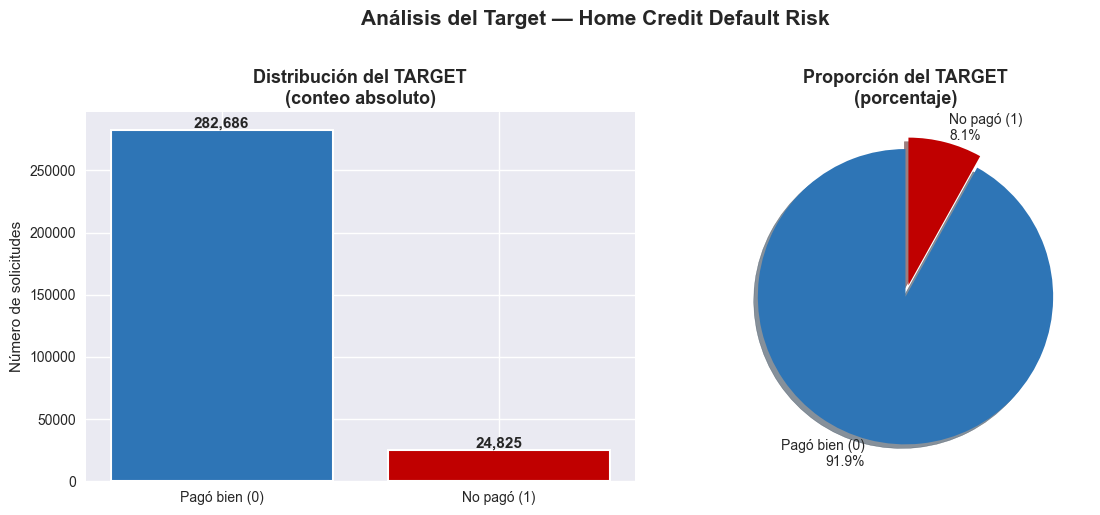

In [8]:
# --- GRÁFICA DE DISTRIBUCIÓN DEL TARGET ---

# Creamos una figura con dos gráficas lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Colores para buenos y malos
colores = ['#2E75B6', '#C00000']  # Azul para buenos, rojo para malos
etiquetas = ['Pagó bien (0)', 'No pagó (1)']

# GRÁFICA 1: Barras con conteo absoluto
conteo = df['TARGET'].value_counts()
axes[0].bar(etiquetas, conteo.values, color=colores, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribución del TARGET\n(conteo absoluto)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Número de solicitudes')

# Agregar etiquetas encima de cada barra
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontweight='bold', fontsize=11)

# GRÁFICA 2: Pie chart con porcentajes
porcentaje = df['TARGET'].value_counts(normalize=True) * 100
axes[1].pie(
    porcentaje.values,
    labels=[f'{e}\n{p:.1f}%' for e, p in zip(etiquetas, porcentaje.values)],
    colors=colores,
    startangle=90,
    explode=(0, 0.08),   # Separar ligeramente el slice de "No pagó"
    shadow=True
)
axes[1].set_title('Proporción del TARGET\n(porcentaje)', fontsize=13, fontweight='bold')

# Título general
fig.suptitle('Análisis del Target — Home Credit Default Risk',
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()

# Guardar la gráfica en reports/
plt.savefig('reports/01_distribucion_target.png', dpi=150, bbox_inches='tight')
print("Gráfica guardada en reports/01_distribucion_target.png")

plt.show()